In [1]:
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

from data_helpers import prepare_this_data, torchify_this_data
from model_stuff import model_setup
from CoupledModel import CoupledModel

Epoch 0 with train loss: 0.022678395683566728 and eval loss: 0.02336398278303603
Epoch 1 with train loss: 0.02145453798274199 and eval loss: 0.021318773580516908
Epoch 2 with train loss: 0.020376059350868066 and eval loss: 0.020408551981474492
Epoch 3 with train loss: 0.019976049860318503 and eval loss: 0.02011118123823024
Epoch 4 with train loss: 0.01954129575441281 and eval loss: 0.019916840531724565
Epoch 5 with train loss: 0.01946413657317559 and eval loss: 0.02011547283210019
Epoch 6 with train loss: 0.019161168336868286 and eval loss: 0.019795503328613778
Epoch 7 with train loss: 0.01932443093508482 and eval loss: 0.019837867607303123
Epoch 8 with train loss: 0.019112840481102466 and eval loss: 0.019973335391346443
Epoch 9 with train loss: 0.01900360162059466 and eval loss: 0.01976429195480144
Epoch 10 with train loss: 0.018840705007314683 and eval loss: 0.019672927565555623
Epoch 11 with train loss: 0.018959575382371745 and eval loss: 0.01959482841986291


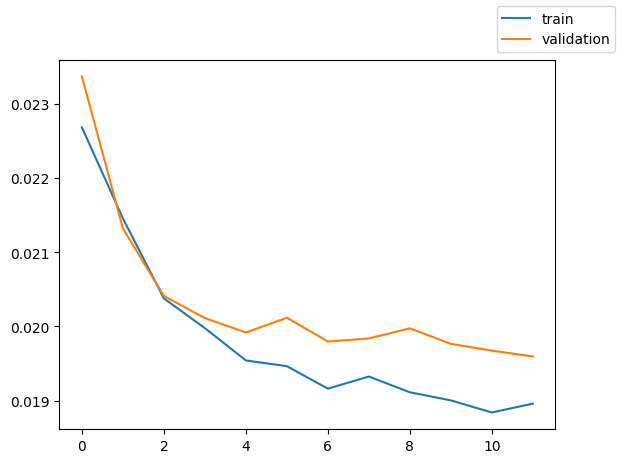

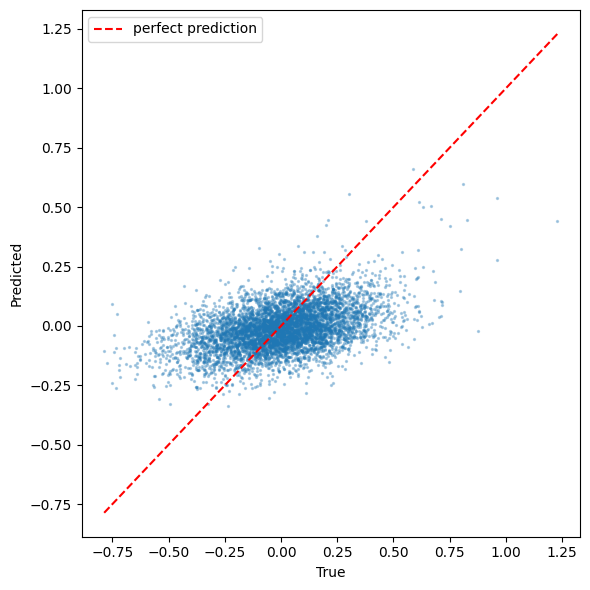

Epoch 0 with train loss: 0.053740622798601784 and eval loss: 0.04938519639062121
Epoch 1 with train loss: 0.052811496704816815 and eval loss: 0.049516057437087625
Epoch 2 with train loss: 0.05247486929098765 and eval loss: 0.048606738804819735
Epoch 3 with train loss: 0.05189376533031464 and eval loss: 0.04831362004451295
Epoch 4 with train loss: 0.0516216238339742 and eval loss: 0.04886041082283284
Epoch 5 with train loss: 0.051387306253115335 and eval loss: 0.04819294207907738
Epoch 6 with train loss: 0.05136333311597506 and eval loss: 0.04824144718177775
Epoch 7 with train loss: 0.051292873173952105 and eval loss: 0.048237172292268024
Epoch 8 with train loss: 0.051057279060284295 and eval loss: 0.04825939931609529
Epoch 9 with train loss: 0.051134745180606844 and eval loss: 0.04814863272328326
Epoch 10 with train loss: 0.050914548337459564 and eval loss: 0.04805325249091108
Epoch 11 with train loss: 0.0509257365266482 and eval loss: 0.04800178221565612


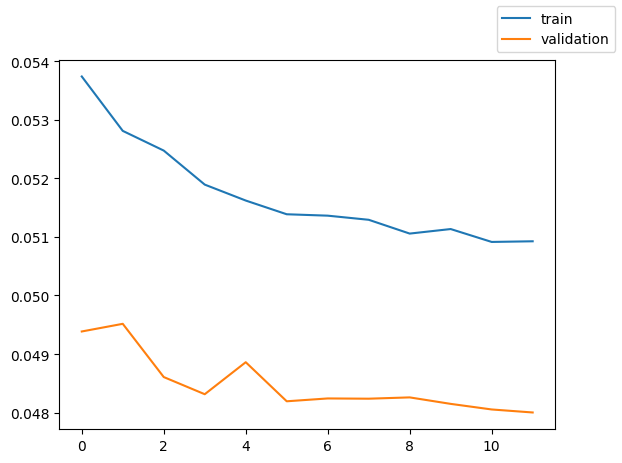

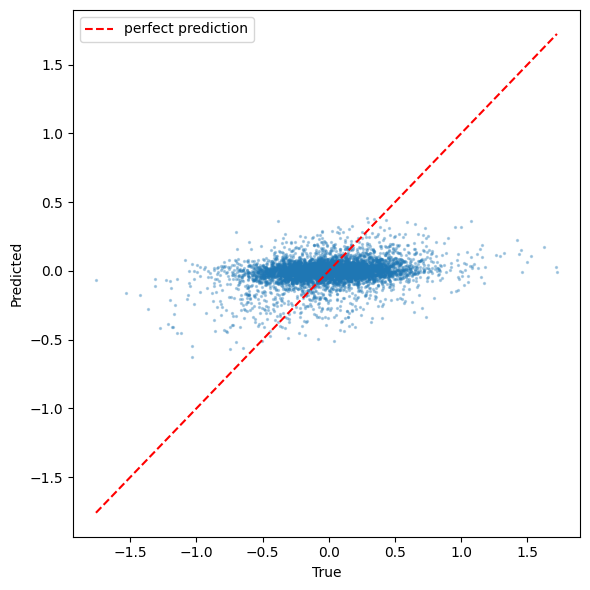

Epoch 0 with train loss: 0.004964057579636574 and eval loss: 0.004118171897023282
Epoch 1 with train loss: 0.0037206902634352446 and eval loss: 0.003593998282474089
Epoch 2 with train loss: 0.0033642180419216554 and eval loss: 0.0033122196055433537
Epoch 3 with train loss: 0.0032016748903940123 and eval loss: 0.0031942173472031
Epoch 4 with train loss: 0.0030843246169388293 and eval loss: 0.003122372810352356
Epoch 5 with train loss: 0.003007663308332364 and eval loss: 0.0030306830947743136
Epoch 6 with train loss: 0.002994929306829969 and eval loss: 0.003030005394124446
Epoch 7 with train loss: 0.002963188615006705 and eval loss: 0.003045705652379609
Epoch 8 with train loss: 0.0029165182138482727 and eval loss: 0.0030245272903405922
Epoch 9 with train loss: 0.002920722250516216 and eval loss: 0.002997665126074819
Epoch 10 with train loss: 0.002930371317391594 and eval loss: 0.002991437211018452
Epoch 11 with train loss: 0.002856188357497255 and eval loss: 0.002986807916115256


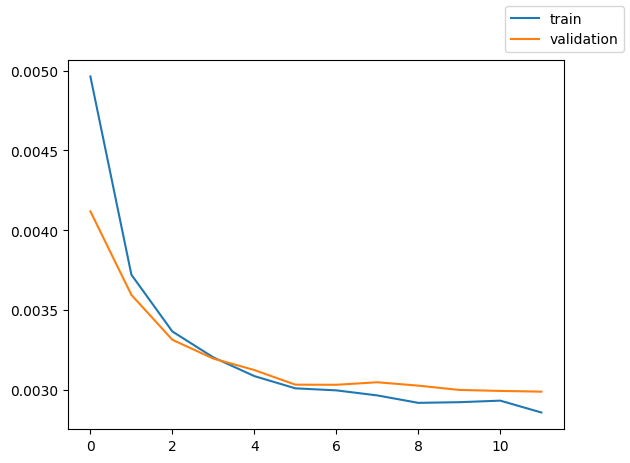

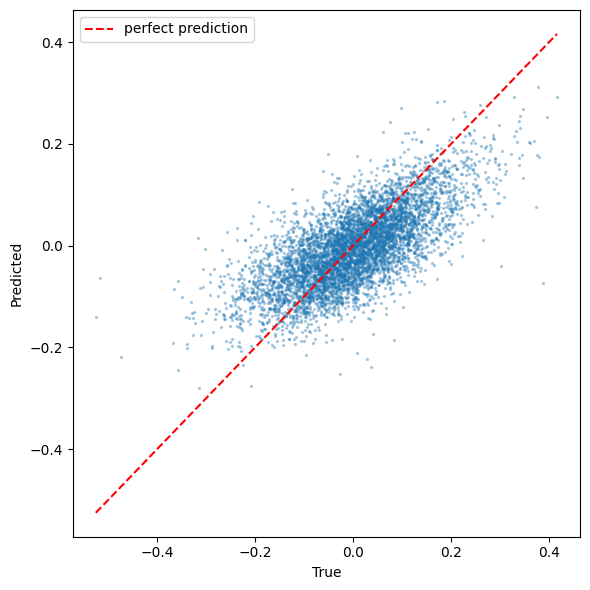

Epoch 0 with train loss: 0.006071555304030577 and eval loss: 0.005491471160797679
Epoch 1 with train loss: 0.0051754463650286195 and eval loss: 0.005244453828979997
Epoch 2 with train loss: 0.004909494180853168 and eval loss: 0.00500720150352634
Epoch 3 with train loss: 0.004526902558282018 and eval loss: 0.004744924466185113
Epoch 4 with train loss: 0.004398012099166711 and eval loss: 0.004390188809880551
Epoch 5 with train loss: 0.004249731106683612 and eval loss: 0.004323527454695803
Epoch 6 with train loss: 0.00421302091019849 and eval loss: 0.004300232434229172
Epoch 7 with train loss: 0.004147876854985953 and eval loss: 0.004231019698558969
Epoch 8 with train loss: 0.0041717395869394144 and eval loss: 0.004313332781671209
Epoch 9 with train loss: 0.004170808456838131 and eval loss: 0.004272135034045006
Epoch 10 with train loss: 0.004073895464340845 and eval loss: 0.004149463280361701
Epoch 11 with train loss: 0.004027497234443823 and eval loss: 0.004128804440273249


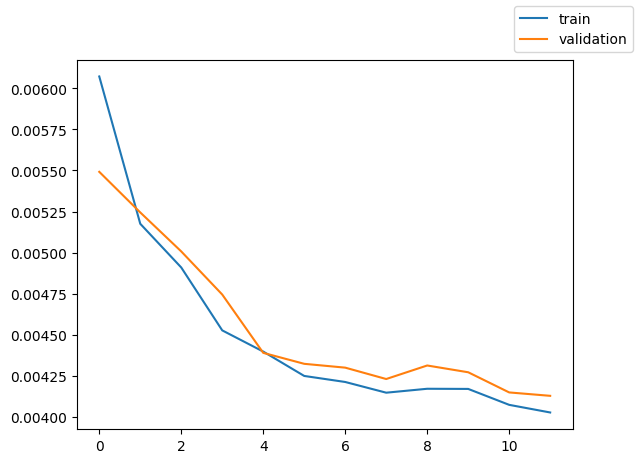

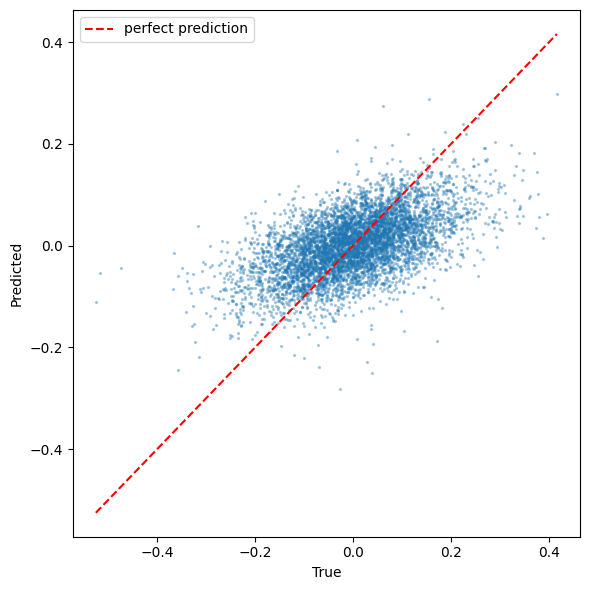

In [3]:
X = pd.read_csv('../data/CESMDataset_Try.csv')

model_configs = {
    'AMOC':    {'target_col': 'AMOC',    'feature_cols': ['SFWF', 'PD_200m', 'ICEFRAC', 'NAO']},
    'SFWF':    {'target_col': 'SFWF',    'feature_cols': ['AMOC', 'PD_200m', 'ICEFRAC', 'NAO']},
    'PD_200m': {'target_col': 'PD_200m', 'feature_cols': ['SFWF', 'AMOC', 'ICEFRAC', 'NAO']},
    'ICEFRAC': {'target_col': 'ICEFRAC', 'feature_cols': ['SFWF', 'PD_200m', 'AMOC', 'NAO']},
    'NAO': {'target_col': 'PD_200m', 'feature_cols': ['SFWF', 'PD_200m', 'ICEFRAC', 'AMOC']},
}

train_cut_1 = 5000
train_cut_2 = 11000
batch_size  = 128
n_epochs    = 12
device      = 'cpu'
lag = 100
horizon = 1
delta = True

params = {
    'n_features': 4,
    'hidden_size': 64,
    'num_layers': 1,
    'dropout': 0.0,
    'lr': 1e-3,
    'loss_fn': nn.HuberLoss(delta=0.5)

}

trained_models = {}

for name, config in model_configs.items():
    X_train_lag, y_train_lag, X_eval_lag, y_eval_lag, y_scaler, x_scaler = prepare_this_data(
        X, config['target_col'], config['feature_cols'],
        train_cut_1, train_cut_2, lag, horizon, delta = delta
    )
    X_train_t, y_train_t, train_loader, X_eval_t, y_eval_t, eval_loader = torchify_this_data(
        batch_size, X_train_lag, y_train_lag, X_eval_lag, y_eval_lag
    )
    model, _, _ = model_setup(device, params, n_epochs, train_loader, eval_loader, eval=True, X_eval_t=X_eval_t, y_eval_lag=y_eval_lag)
    trained_models[name] = {'model': model, 'y_scaler': y_scaler, 'x_scaler': x_scaler}

/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


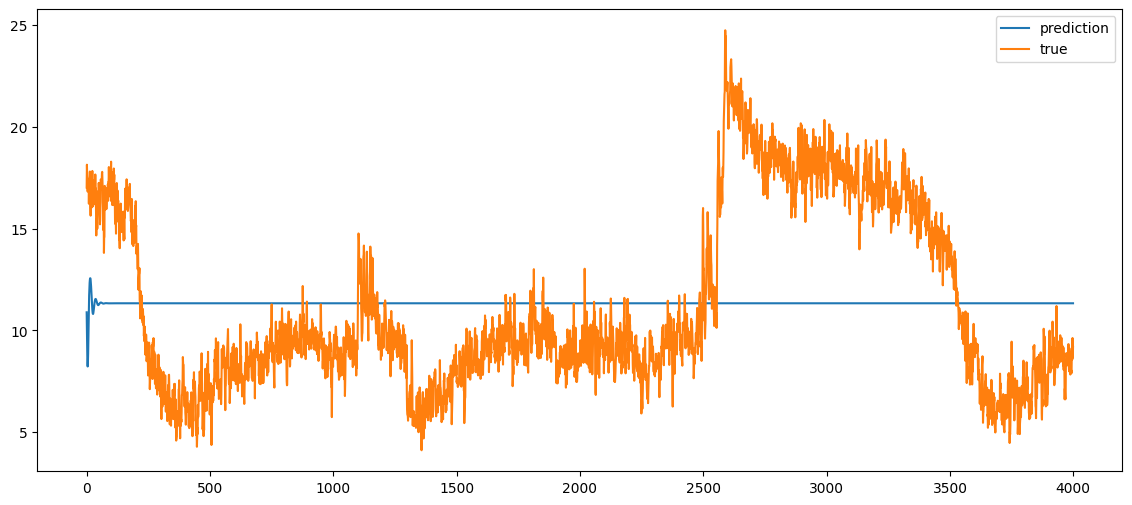

In [6]:
coupled = CoupledModel.from_trained(trained_models)

rho = 0.0
k = 0.0

start_idx = 6600
models = ['AMOC', 'SFWF', 'PD_200m', 'NAO']

features = {
    'AMOC':    ['SFWF', 'PD_200m', 'NAO'],
    'SFWF':    ['AMOC', 'PD_200m', 'NAO'],
    'PD_200m': ['SFWF', 'AMOC', 'NAO'],
    #'ICEFRAC': ['SFWF', 'PD_200m', 'AMOC', 'NAO'],
    'NAO': ['SFWF', 'PD_200m', 'AMOC'],
}

steps = 4000
threshold = 13

predictions = coupled.predict(device, X, start_idx, lag, horizon, models, features, steps, threshold, rho, k)

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, predictions['AMOC'], label = 'prediction')
plt.plot(x, X['AMOC'][start_idx:start_idx+4000], label = 'true')
plt.legend()